In [62]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [63]:
np.random.seed(0)

orientations = np.linspace(0, 180, num=16, endpoint=False)
N = 40000
H, W = 16, 16
num_cycles = 3
period = H / num_cycles

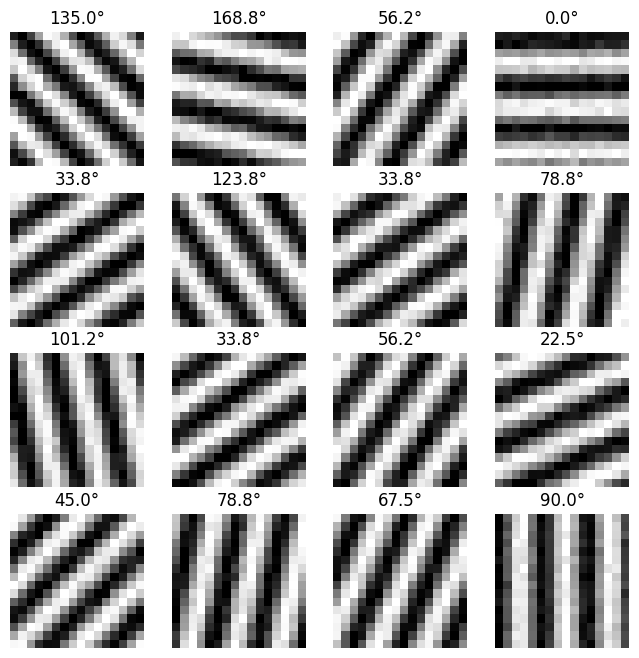

In [64]:
x = np.arange(H)
y = np.arange(W)
X, Y = np.meshgrid(x, y, indexing='ij')

thetas = np.deg2rad(orientations)
cos_t = np.cos(thetas)[:, None, None]
sin_t = np.sin(thetas)[:, None, None]

A = 2 * np.pi * (cos_t * X[None, :, :] + sin_t * Y[None, :, :]) / period

cosA = np.cos(A)
sinA = np.sin(A)

idx_oris = np.random.choice(len(orientations), size=N, replace=True)
phases = np.random.rand(N) * 2 * np.pi
cphi = np.cos(phases)[:, None, None]
sphi = np.sin(phases)[:, None, None]

cosA_sel = cosA[idx_oris]
sinA_sel = sinA[idx_oris]

gratings = 0.5 * (1 + (cosA_sel * cphi - sinA_sel * sphi))

noise = np.random.normal(0, 0.05, size=(N, H, W))
train_imgs = np.clip(gratings + noise, 0, 1)

fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(train_imgs[i * 4 + j], cmap='gray')
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{orientations[idx_oris[i * 4 + j]]:.1f}°')

In [65]:
sio.savemat('train_gratings.mat', {'images': train_imgs, 'orientations': orientations[idx_oris]})

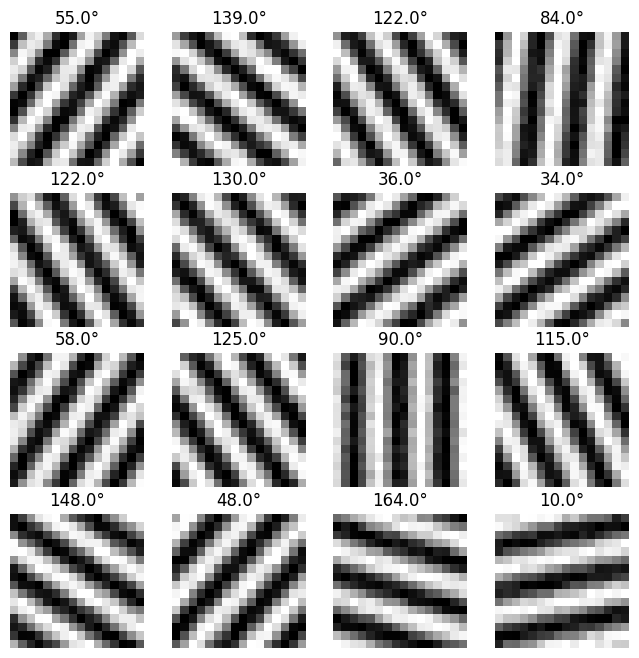

In [66]:
orientations = np.arange(0, 180)
trials = 30

x = np.arange(H)
y = np.arange(W)
X, Y = np.meshgrid(x, y, indexing='ij')

thetas = np.deg2rad(orientations)
cos_t = np.cos(thetas)[:, None, None]
sin_t = np.sin(thetas)[:, None, None]

A = 2 * np.pi * (cos_t * X[None, :, :] + sin_t * Y[None, :, :]) / period

cosA = np.cos(A)
sinA = np.sin(A)

idx_oris = np.repeat(orientations, trials)
phases = np.random.rand(len(orientations) * trials) * 2 * np.pi
cphi = np.cos(phases)[:, None, None]
sphi = np.sin(phases)[:, None, None]

cosA_sel = cosA[idx_oris]
sinA_sel = sinA[idx_oris]

gratings = 0.5 * (1 + (cosA_sel * cphi - sinA_sel * sphi))

noise = np.random.normal(0, 0.05, size=(len(orientations) * trials, H, W))
test_imgs = np.clip(gratings + noise, 0, 1)

fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        idx = np.random.randint(len(test_imgs))
        axs[i, j].imshow(test_imgs[idx], cmap='gray')
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{orientations[idx_oris[idx]]:.1f}°')

In [67]:
sio.savemat('test_gratings.mat', {'images': test_imgs, 'orientations': orientations[idx_oris]})

In [68]:
print(f'All training and testing images take up {(train_imgs.nbytes + test_imgs.nbytes) / (2 ** 10):.2f} MB combined.')

All training and testing images take up 90800.00 MB combined.
